In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent)) 

from src.config import PATHS
import pandas as pd

metrics_df = pd.read_parquet(PATHS.RESULTS_DATASET)
labeled_df = pd.read_parquet(PATHS.LABELED_DATASET)

merged = metrics_df.merge(
    labeled_df[["instance_id", "resolved"]],
    on="instance_id",
    how="left",
)

clean = merged[
    merged["parsable"] 
    & merged["lm_cc_score"].notna() 
    & merged["resolved"].notna()
].copy()

print(f"Total: {len(merged)}")
print(f"Usable: {len(clean)}")
print(f"Resolve rate: {clean['resolved'].mean():.1%}")

Total: 427
Usable: 404
Resolve rate: 56.2%


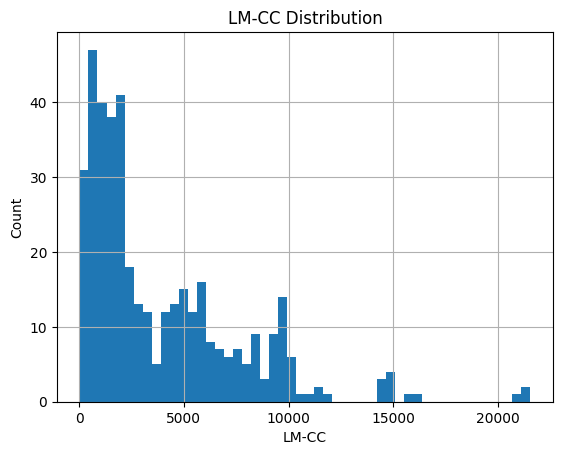

In [2]:
import matplotlib.pyplot as plt

clean["lm_cc_score"].describe()

clean["lm_cc_score"].hist(bins=50)
plt.xlabel("LM-CC")
plt.ylabel("Count")
plt.title("LM-CC Distribution")
plt.show()

In [3]:
from src.correlation import full_correlation_table

metrics_to_compare = [
    "cc_avg",
    "cc_max", 
    "cc_sum",
    "halstead_volume",
    "halstead_difficulty",
    "halstead_effort",
    "loc",
    "lloc",
    "nesting_max",
    "token_count",
    "function_count",
    "n_branches",
    
    "lm_cc_max_comp",      
    "lm_cc_avg_comp",      
    "lm_cc_total_comp",    
    "lm_cc_max_branch",   
    "lm_cc_avg_branch",    
    "lm_cc_total_branch",  
    
    "lm_cc_score",
]
available_metrics = [m for m in metrics_to_compare if m in clean.columns]

result_table = full_correlation_table(clean, available_metrics)
print("=== Full Correlation Table (vs. resolved) ===")
print(result_table.to_string(index=False))

=== Full Correlation Table (vs. resolved) ===
             metric      sample_zero sample_partial_loc          subgroup_zero   subgroup_partial_loc
             cc_avg -0.010 (p=0.843)   +0.004 (p=0.939) -0.333 (p=0.347, n=10) -0.353 (p=0.366, n=10)
             cc_max -0.034 (p=0.497)   +0.042 (p=0.404) -0.394 (p=0.260, n=10) +0.287 (p=0.469, n=10)
             cc_sum -0.111 (p=0.025)   -0.020 (p=0.689)  -0.617 (p=0.077, n=9) -0.000 (p=1.000, n=10)
    halstead_volume -0.089 (p=0.074)   +0.032 (p=0.521) -0.500 (p=0.117, n=11) -0.000 (p=1.000, n=10)
halstead_difficulty -0.055 (p=0.266)   +0.037 (p=0.460)  -0.487 (p=0.183, n=9)  +0.325 (p=0.451, n=9)
    halstead_effort -0.086 (p=0.086)   +0.034 (p=0.502) -0.556 (p=0.075, n=11) -0.000 (p=1.000, n=10)
                loc -0.109 (p=0.028)                  — -0.503 (p=0.138, n=10)                      —
               lloc -0.103 (p=0.038)   +0.086 (p=0.086)  -0.500 (p=0.170, n=9) -0.000 (p=1.000, n=10)
        nesting_max -0.074 (p=0.136)

In [4]:
classical = ["cc_avg", "cc_max", "cc_sum", "halstead_volume", "halstead_difficulty",
             "halstead_effort", "loc", "lloc", "nesting_max", "token_count",
             "function_count", "n_branches"]
lm_cc_components = ["lm_cc_max_comp", "lm_cc_avg_comp", "lm_cc_total_comp",
                    "lm_cc_max_branch", "lm_cc_avg_branch", "lm_cc_total_branch"]
lm_cc_final = ["lm_cc_score"]

print("=" * 100)
print("Classic Metrics")
print("=" * 100)
print(result_table[result_table["metric"].isin(classical)].to_string(index=False))

print("\n" + "=" * 100)
print("LM-CC SUB-FEATURES (Paper Table 2)")
print("=" * 100)
print(result_table[result_table["metric"].isin(lm_cc_components)].to_string(index=False))

print("\n" + "=" * 100)
print("LM-CC (composite, Paper Table 2 last column)")
print("=" * 100)
print(result_table[result_table["metric"].isin(lm_cc_final)].to_string(index=False))

Classic Metrics
             metric      sample_zero sample_partial_loc          subgroup_zero   subgroup_partial_loc
             cc_avg -0.010 (p=0.843)   +0.004 (p=0.939) -0.333 (p=0.347, n=10) -0.353 (p=0.366, n=10)
             cc_max -0.034 (p=0.497)   +0.042 (p=0.404) -0.394 (p=0.260, n=10) +0.287 (p=0.469, n=10)
             cc_sum -0.111 (p=0.025)   -0.020 (p=0.689)  -0.617 (p=0.077, n=9) -0.000 (p=1.000, n=10)
    halstead_volume -0.089 (p=0.074)   +0.032 (p=0.521) -0.500 (p=0.117, n=11) -0.000 (p=1.000, n=10)
halstead_difficulty -0.055 (p=0.266)   +0.037 (p=0.460)  -0.487 (p=0.183, n=9)  +0.325 (p=0.451, n=9)
    halstead_effort -0.086 (p=0.086)   +0.034 (p=0.502) -0.556 (p=0.075, n=11) -0.000 (p=1.000, n=10)
                loc -0.109 (p=0.028)                  — -0.503 (p=0.138, n=10)                      —
               lloc -0.103 (p=0.038)   +0.086 (p=0.086)  -0.500 (p=0.170, n=9) -0.000 (p=1.000, n=10)
        nesting_max -0.074 (p=0.136)   -0.015 (p=0.767)  -0.543 (p

In [5]:
high_resolved = clean[clean["resolved"] == 1].nlargest(5, "lm_cc_score")
print("=== High LM-CC, resolved ===")
print(high_resolved[["instance_id", "lm_cc_score", "loc", "cc_sum", "nesting_max"]].to_string(index=False))

high_failed = clean[clean["resolved"] == 0].nlargest(5, "lm_cc_score")
print("=== High LM-CC, not resolved ===")
print(high_failed[["instance_id", "lm_cc_score", "loc", "cc_sum", "nesting_max"]].to_string(index=False))

low_resolved = clean[clean["resolved"] == 1].nsmallest(5, "lm_cc_score")
print("\n=== Low LM-CC, resolved ===")
print(low_resolved[["instance_id", "lm_cc_score", "loc", "cc_sum", "nesting_max"]].to_string(index=False))

low_failed = clean[clean["resolved"] == 0].nsmallest(5, "lm_cc_score")
print("\n=== Low LM-CC, not resolved ===")
print(low_failed[["instance_id", "lm_cc_score", "loc", "cc_sum", "nesting_max"]].to_string(index=False))

=== High LM-CC, resolved ===
                 instance_id  lm_cc_score    loc  cc_sum  nesting_max
matplotlib__matplotlib-26113      21538.0 2501.0   755.0          6.0
matplotlib__matplotlib-24149      21148.8 2460.0   745.0          6.0
matplotlib__matplotlib-13989      20962.2 2542.0   707.0          6.0
matplotlib__matplotlib-24627      14856.6 2008.0   712.0          9.0
         pydata__xarray-3677      14806.2 1972.0   779.0          9.0
=== High LM-CC, not resolved ===
                 instance_id  lm_cc_score    loc  cc_sum  nesting_max
          sympy__sympy-18698      16260.4 2947.0   900.0          6.0
          sympy__sympy-13757      15919.2 2907.0   885.0          6.0
matplotlib__matplotlib-26208      14431.0 1966.0   703.0          9.0
matplotlib__matplotlib-24177      14364.6 1936.0   680.0         10.0
          sympy__sympy-18763      14274.0 1989.0   688.0          7.0

=== Low LM-CC, resolved ===
                     instance_id  lm_cc_score   loc  cc_sum  nesting_

In [6]:
import numpy as np

print("=== LM-CC: resolved vs. not resolved ===")

resolved_lmcc = clean[clean["resolved"] == 1]["lm_cc_score"]
failed_lmcc = clean[clean["resolved"] == 0]["lm_cc_score"]

print("LM-CC on resolved tasks:")
print(f"  Median: {resolved_lmcc.median():.1f}, Mean: {resolved_lmcc.mean():.1f}")
print(f"  Range: {resolved_lmcc.min():.1f} – {resolved_lmcc.max():.1f}")

print("\nLM-CC on not resolved tasks:")
print(f"  Median: {failed_lmcc.median():.1f}, Mean: {failed_lmcc.mean():.1f}")
print(f"  Range: {failed_lmcc.min():.1f} – {failed_lmcc.max():.1f}")

from scipy.stats import mannwhitneyu
stat, p = mannwhitneyu(resolved_lmcc, failed_lmcc)
print(f"\nMann-Whitney-U: p={p:.3f}")


=== LM-CC: resolved vs. not resolved ===
LM-CC on resolved tasks:
  Median: 1924.4, Mean: 3673.9
  Range: 47.8 – 21538.0

LM-CC on not resolved tasks:
  Median: 3182.0, Mean: 4121.1
  Range: 12.0 – 16260.4

Mann-Whitney-U: p=0.046


In [7]:
from scipy.stats import spearmanr

metrics = ["lm_cc_score", "lm_cc_total_comp", "lm_cc_total_branch",
           "cc_sum", "halstead_volume", "lloc", "nesting_max", "n_branches"]

print("=== Collinearity with LOC ===")
print(f"{'Metric':<22} {'ρ with LOC':>10}")
for m in metrics:
    rho, _ = spearmanr(clean[m], clean["loc"])
    print(f"{m:<22} {rho:>+10.3f}")

=== Collinearity with LOC ===
Metric                 ρ with LOC
lm_cc_score                +0.983
lm_cc_total_comp           +0.977
lm_cc_total_branch         +0.985
cc_sum                     +0.976
halstead_volume            +0.925
lloc                       +0.998
nesting_max                +0.569
n_branches                 +0.949


In [8]:
print("=== Descriptive Statistics ===")

metrics = ["lm_cc_score", "lm_cc_total_comp", "lm_cc_total_branch", "lm_cc_max_comp",
           "cc_sum", "halstead_volume", "loc", "lloc", "nesting_max", "n_branches"]

desc = clean[metrics].describe().T  # transponiert: Metriken als Zeilen
desc = desc[["count", "mean", "std", "min", "25%", "50%", "75%", "max"]]
print(desc.round(2).to_string())

# Resolve-Rate
print(f"\nResolve rate: {clean['resolved'].mean():.1%}")
print(f"Total tasks: {len(clean)}")
print(f"Resolved: {clean['resolved'].sum()}, Not resolved: {(~clean['resolved'].astype(bool)).sum()}")

=== Descriptive Statistics ===
                    count     mean      std   min      25%      50%       75%       max
lm_cc_score         404.0  3869.85  3729.97  12.0  1094.25  2302.90   5722.80  21538.00
lm_cc_total_comp    404.0  9151.57  8942.72  28.0  2527.50  5233.00  13472.75  52250.00
lm_cc_total_branch  404.0  2549.42  2434.39   4.0   761.00  1538.50   3769.75  13860.00
lm_cc_max_comp      404.0     6.74     1.60   2.0     6.00     7.00      8.00     11.00
cc_sum              404.0   218.24   192.30   1.0    67.50   141.50    350.00    900.00
halstead_volume     404.0  3627.70  4803.03   0.0   707.61  1668.22   5590.69  37272.93
loc                 404.0   576.80   516.95   6.0   196.00   389.50    856.50   2947.00
lloc                404.0   528.15   480.13   5.0   181.00   349.00    774.75   2686.00
nesting_max         404.0     5.02     2.43   0.0     3.00     5.00      6.00     14.00
n_branches          404.0   103.30   101.78   0.0    28.75    61.50    169.25    536.00



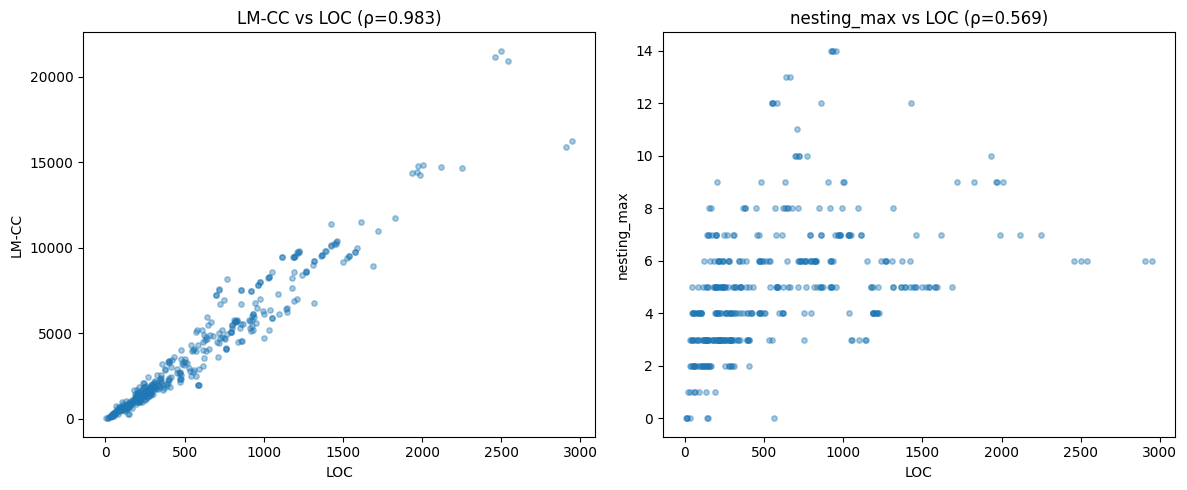

In [9]:
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

rho1, _ = spearmanr(clean["lm_cc_score"], clean["loc"])
axes[0].scatter(clean["loc"], clean["lm_cc_score"], alpha=0.4, s=15)
axes[0].set_xlabel("LOC"); axes[0].set_ylabel("LM-CC")
axes[0].set_title(f"LM-CC vs LOC (ρ={rho1:.3f})")

rho2, _ = spearmanr(clean["nesting_max"], clean["loc"])
axes[1].scatter(clean["loc"], clean["nesting_max"], alpha=0.4, s=15)
axes[1].set_xlabel("LOC"); axes[1].set_ylabel("nesting_max")
axes[1].set_title(f"nesting_max vs LOC (ρ={rho2:.3f})")

plt.tight_layout()
plt.savefig("collinearity.png", dpi=150)
plt.show()